In [3]:
import pandas as pd

In [4]:
transactions = pd.read_excel(r"C:\Users\Subhasish\Desktop\anjali\EXCEL\online_retail_II.xlsx", sheet_name= "Year 2010-2011")

In [5]:
customers = pd.read_excel(r"C:\Users\Subhasish\Desktop\anjali\EXCEL\online_retail_II.xlsx", sheet_name= "rfm 2")

In [6]:
transactions.info()
transactions.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539258 entries, 0 to 539257
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   Invoice             539258 non-null  int64         
 1   Description         539258 non-null  object        
 2   Quantity            539258 non-null  int64         
 3   InvoiceDate         539258 non-null  datetime64[ns]
 4   Price               539258 non-null  float64       
 5   Country             539258 non-null  object        
 6   Revenue             539258 non-null  float64       
 7   clean Stock Code    536429 non-null  float64       
 8   clean customer id   406778 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(2)
memory usage: 37.0+ MB


Invoice                    0
Description                0
Quantity                   0
InvoiceDate                0
Price                      0
Country                    0
Revenue                    0
clean Stock Code        2829
clean customer id     132480
dtype: int64

In [7]:
transactions.duplicated().sum()

5331

In [8]:
transactions[["Quantity", "Price", "Revenue"]].describe()

,Quantity,Price,Revenue
count,539258.000000,539258.000000,539258.000000
mean,10.877569,4.172697,20.941236
std,215.389845,63.514527,372.439710
min,1.000000,0.001000,0.001000
25%,1.000000,1.250000,3.750000
50%,3.000000,2.080000,9.900000
75%,10.000000,4.130000,17.700000
max,80995.000000,38970.000000,168469.600000


In [9]:
import numpy as np

In [10]:
print(transactions.columns.tolist())

['Invoice', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Country', 'Revenue', 'clean Stock Code ', 'clean customer id ']


In [11]:
transactions = transactions.dropna(
    subset=["clean customer id ", "clean Stock Code "]
)

In [12]:
transactions.isna().sum()

Invoice               0
Description           0
Quantity              0
InvoiceDate           0
Price                 0
Country               0
Revenue               0
clean Stock Code      0
clean customer id     0
dtype: int64

In [13]:
transactions = transactions.drop_duplicates()

In [14]:
transactions.duplicated().sum()

0

In [15]:
transactions[["Quantity", "Price", "Revenue"]].quantile(
    [0.01, 0.25, 0.50, 0.75, 0.99]
)

,Quantity,Price,Revenue
0.01,1.0,0.21,0.55
0.25,2.0,1.25,4.95
0.50,6.0,1.95,11.90
0.75,12.0,3.75,19.80
0.99,125.0,12.75,203.52


In [16]:
customer_features = transactions.groupby("clean customer id ").agg(
    Recency=("InvoiceDate", lambda x: (transactions["InvoiceDate"].max() - x.max()).days),
    Frequency=("Invoice", "nunique"),
    Monetary=("Revenue", "sum"),
    Total_Quantity=("Quantity", "sum"),
    Unique_Products=("clean Stock Code ", "nunique"),
    First_Purchase=("InvoiceDate", "min"),
    Last_Purchase=("InvoiceDate", "max")
).reset_index()

In [17]:
customer_features["AOV"] = (
    customer_features["Monetary"] /
    customer_features["Frequency"]
)

In [18]:
customer_features.head()

,clean customer id,Recency,Frequency,Monetary,Total_Quantity,Unique_Products,First_Purchase,Last_Purchase,AOV
0,12346.0,325,2,154367.20,148430,1,2011-01-18 10:01:00,2011-01-18 10:17:00,77183.600000
1,12347.0,1,7,4310.00,2458,99,2010-12-07 14:57:00,2011-12-07 15:52:00,615.714286
2,12348.0,74,4,1437.24,2332,21,2010-12-16 19:09:00,2011-09-25 13:13:00,359.310000
3,12349.0,18,1,1457.55,630,71,2011-11-21 09:51:00,2011-11-21 09:51:00,1457.550000
4,12350.0,309,1,294.40,196,16,2011-02-02 16:01:00,2011-02-02 16:01:00,294.400000


In [19]:
customer_features['First_Purchase'] = pd.to_datetime(customer_features['First_Purchase'])

# Reset time component to midnight
customer_features['First_Purchase'] = customer_features['First_Purchase'].dt.normalize()

customer_features['Last_Purchase'] = pd.to_datetime(customer_features['Last_Purchase'])
customer_features['Last_Purchase'] = customer_features['Last_Purchase'].dt.normalize()
customer_features.head()


,clean customer id,Recency,Frequency,Monetary,Total_Quantity,Unique_Products,First_Purchase,Last_Purchase,AOV
0,12346.0,325,2,154367.20,148430,1,2011-01-18,2011-01-18,77183.600000
1,12347.0,1,7,4310.00,2458,99,2010-12-07,2011-12-07,615.714286
2,12348.0,74,4,1437.24,2332,21,2010-12-16,2011-09-25,359.310000
3,12349.0,18,1,1457.55,630,71,2011-11-21,2011-11-21,1457.550000
4,12350.0,309,1,294.40,196,16,2011-02-02,2011-02-02,294.400000


In [20]:
mismatched_purchasedates= customer_features[customer_features['First_Purchase'] != customer_features['Last_Purchase']]
mismatched_purchasedates.head()

,clean customer id,Recency,Frequency,Monetary,Total_Quantity,Unique_Products,First_Purchase,Last_Purchase,AOV
1,12347.0,1,7,4310.00,2458,99,2010-12-07,2011-12-07,615.714286
2,12348.0,74,4,1437.24,2332,21,2010-12-16,2011-09-25,359.310000
5,12352.0,35,8,1506.07,589,57,2011-02-16,2011-11-03,188.258750
9,12356.0,22,3,2487.43,1573,52,2011-01-18,2011-11-17,829.143333
11,12358.0,1,2,928.06,242,10,2011-07-12,2011-12-08,464.030000


In [21]:

customer_features["log_Monetary"] = np.log1p(customer_features["Monetary"])
customer_features["log_Frequency"] = np.log1p(customer_features["Frequency"])

In [22]:
#Scaling

In [23]:
from sklearn.preprocessing import StandardScaler

features = customer_features[
    ["Recency", "log_Frequency", "log_Monetary"]
]

scaler = StandardScaler()
X = scaler.fit_transform(features)

In [24]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

customer_features["Cluster"] = kmeans.fit_predict(X)

In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

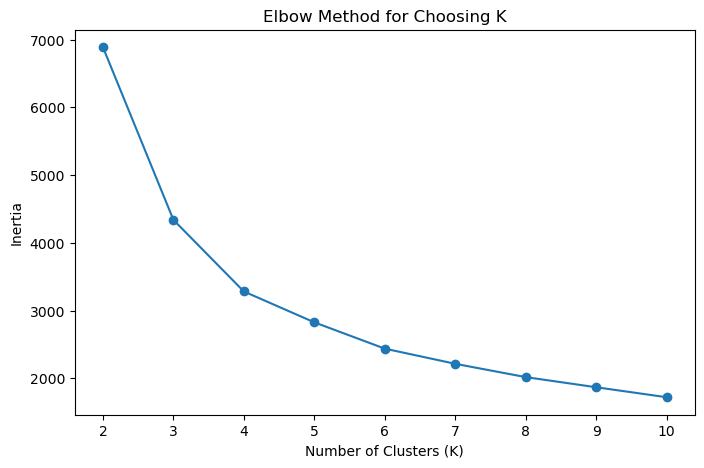

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Choosing K")

plt.show()


In [27]:
inertia_df = pd.DataFrame({
    "K": range(2, 11),
    "Inertia": inertia
})

inertia_df

,K,Inertia
0,2,6886.717141
1,3,4338.955331
2,4,3282.273322
3,5,2826.756797
4,6,2438.580830
5,7,2214.819070
6,8,2018.455948
7,9,1868.925060
8,10,1721.593774


In [28]:
#elbow is at k=3

In [29]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X)
    
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

In [30]:
silhouette_df = pd.DataFrame({
    "K": range(2, 11),
    "Silhouette Score": silhouette_scores
})

silhouette_df.round(3)

,K,Silhouette Score
0,2,0.408
1,3,0.413
2,4,0.379
3,5,0.338
4,6,0.327
5,7,0.301
6,8,0.299
7,9,0.294
8,10,0.282


In [31]:
#running final kmeans with k=3

In [32]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_features["Cluster"] = kmeans.fit_predict(X)

In [33]:
customer_features.head()

,clean customer id,Recency,Frequency,Monetary,Total_Quantity,Unique_Products,First_Purchase,Last_Purchase,AOV,log_Monetary,log_Frequency,Cluster
0,12346.0,325,2,154367.20,148430,1,2011-01-18,2011-01-18,77183.600000,11.947096,1.098612,0
1,12347.0,1,7,4310.00,2458,99,2010-12-07,2011-12-07,615.714286,8.368925,2.079442,0
2,12348.0,74,4,1437.24,2332,21,2010-12-16,2011-09-25,359.310000,7.271175,1.609438,2
3,12349.0,18,1,1457.55,630,71,2011-11-21,2011-11-21,1457.550000,7.285198,0.693147,2
4,12350.0,309,1,294.40,196,16,2011-02-02,2011-02-02,294.400000,5.688330,0.693147,1


In [34]:
cluster_profile = customer_features.groupby("Cluster").agg(
    Customers=("clean customer id ", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Avg_AOV=("AOV", "mean")
).round(2)

cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_AOV
Cluster,,,,,
0,1369,28.98,11.49,5569.14,569.27
1,971,256.56,1.55,380.23,261.75
2,2022,53.86,2.25,601.11,305.99


In [35]:
cluster_profile["Customer_%"] = (
    cluster_profile["Customers"] /
    cluster_profile["Customers"].sum() * 100
).round(2)

cluster_profile["Revenue_%"] = (
    customer_features.groupby("Cluster")["Monetary"].sum() /
    customer_features["Monetary"].sum() * 100
).round(2)

In [36]:
cluster_profile

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Avg_AOV,Customer_%,Revenue_%
Cluster,,,,,,,
0,1369,28.98,11.49,5569.14,569.27,31.38,82.79
1,971,256.56,1.55,380.23,261.75,22.26,4.01
2,2022,53.86,2.25,601.11,305.99,46.35,13.20


In [37]:
print(customers.columns.tolist())

['Customer ID', 'Max of InvoiceDate', 'Count of Invoie', 'Average of Revenue', 'R', 'F', 'M', 'Days since order', 'RFM score', 'Segments ', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']


In [38]:
pd.crosstab(
    customer_features["Cluster"],
    customers["Segments "]
)

Segments,At Risk,Champions,Lost Customers,Loyal Customers,Needs Attention,Potential Loyalists
Cluster,,,,,,
0,356,53,81,164,422,293
1,252,29,59,105,327,199
2,483,53,126,203,726,431


In [39]:
customer_features.to_csv(
    "customer_segmentation.csv",
    index=False
)

In [40]:
transactions.head()

,Invoice,Description,Quantity,InvoiceDate,Price,Country,Revenue,clean Stock Code,clean customer id
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,United Kingdom,15.30,85123.0,17850.0
1,536365,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,United Kingdom,20.34,71053.0,17850.0
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,United Kingdom,22.00,84406.0,17850.0
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,United Kingdom,20.34,84029.0,17850.0
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,United Kingdom,20.34,84029.0,17850.0


In [80]:
transactions.to_csv(
    "transactions.csv",
    index=False
)